In [1]:
import pandas as pd

# Load the file directly from Colab's temporary storage
# It is just sitting right next to our notebook now!
file_path = '/content/ds.csv'
df = pd.read_csv(file_path)

print("Data loaded successfully!")
print(f"Total rows: {len(df)}")

# Let's peek at the receipt
df.head()

Data loaded successfully!
Total rows: 1473166


,subject_id,charttime,lab_test_name,valuenum,valueuom,flag
0,10000032,2180-03-23 11:51:00,Creatinine,0.4,mg/dL,NaN
1,10000032,2180-03-23 11:51:00,INR(PT),1.4,NaN,abnormal
2,10000032,2180-03-23 11:51:00,"Bilirubin, Total",1.6,mg/dL,abnormal
3,10000032,2180-03-23 11:51:00,Platelet Count,83.0,K/uL,abnormal
4,10000032,2180-03-23 11:51:00,Alkaline Phosphatase,109.0,IU/L,abnormal


In [4]:
# Pivot the table so each lab test becomes a column
pivot_df = df.pivot_table(
    index=['subject_id', 'charttime'],
    columns='lab_test_name',
    values='valuenum',
    aggfunc='max'
).reset_index()

# Sort chronologically so time moves forward for each patient
pivot_df = pivot_df.sort_values(by=['subject_id', 'charttime'])

print("Pivot complete! Here is the new ML-ready structure:")
pivot_df.head(10)

Pivot complete! Here is the new ML-ready structure:


lab_test_name,subject_id,charttime,Alanine Aminotransferase (ALT),Alkaline Phosphatase,"Bilirubin, Total",Creatinine,INR(PT),Platelet Count
0,10000032,2180-03-23 11:51:00,102.0,109.0,1.6,0.4,1.4,83.0
1,10000032,2180-05-06 22:25:00,100.0,114.0,1.6,0.3,1.6,71.0
2,10000032,2180-05-07 05:05:00,88.0,103.0,1.3,0.3,1.5,71.0
3,10000032,2180-06-03 12:00:00,110.0,116.0,1.6,0.4,NaN,NaN
4,10000032,2180-06-22 11:15:00,113.0,117.0,1.9,0.3,1.4,113.0
5,10000032,2180-06-26 16:10:00,126.0,117.0,0.9,0.6,NaN,143.0
6,10000032,2180-06-27 05:10:00,117.0,110.0,1.2,0.3,1.5,137.0
7,10000032,2180-07-23 06:39:00,153.0,114.0,1.9,0.7,1.5,145.0
8,10000032,2180-07-23 21:45:00,NaN,NaN,NaN,0.5,NaN,NaN
9,10000032,2180-07-24 06:35:00,114.0,86.0,2.7,0.4,1.8,94.0


In [5]:
# 0. Identify just the lab columns (everything except the IDs and timestamps)
lab_columns = pivot_df.columns.drop(['subject_id', 'charttime'])

# 1. Forward Fill: Only apply it to the lab columns!
print("1. Forward filling gaps...")
pivot_df[lab_columns] = pivot_df.groupby('subject_id')[lab_columns].ffill()

# 2. Backward Fill: Apply it to the lab columns!
print("2. Backward filling initial gaps...")
pivot_df[lab_columns] = pivot_df.groupby('subject_id')[lab_columns].bfill()

# 3. The Purge: Drop any rows that STILL have NaNs
print("3. Dropping unusable rows...")
clean_df = pivot_df.dropna()

print(f"Data cleaning complete! Final ML-ready rows: {len(clean_df)}")
clean_df.head()

1. Forward filling gaps...
2. Backward filling initial gaps...
3. Dropping unusable rows...
Data cleaning complete! Final ML-ready rows: 382397


lab_test_name,subject_id,charttime,Alanine Aminotransferase (ALT),Alkaline Phosphatase,"Bilirubin, Total",Creatinine,INR(PT),Platelet Count
0,10000032,2180-03-23 11:51:00,102.0,109.0,1.6,0.4,1.4,83.0
1,10000032,2180-05-06 22:25:00,100.0,114.0,1.6,0.3,1.6,71.0
2,10000032,2180-05-07 05:05:00,88.0,103.0,1.3,0.3,1.5,71.0
3,10000032,2180-06-03 12:00:00,110.0,116.0,1.6,0.4,1.5,71.0
4,10000032,2180-06-22 11:15:00,113.0,117.0,1.9,0.3,1.4,113.0


In [6]:
# 1. Import the Machine Learning libraries
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings('ignore') # Hides annoying red warning text

print("Setting up the Machine Learning Pipeline...")

# 2. Create the "Answer Key" (Target Variable)
# We define "Decompensation" as Total Bilirubin going over 3.0 mg/dL
# This creates a new column with a 1 (Failed) or 0 (Fine)
clean_df['Decompensated'] = (clean_df['Bilirubin, Total'] > 3.0).astype(int)

# 3. Define the Features (X) and the Answer Key (y)
# X is the data the AI gets to study. We drop the patient ID, the timestamp,
# and the answer key itself (so it can't cheat).
X = clean_df.drop(columns=['subject_id', 'charttime', 'Decompensated', 'Bilirubin, Total'], errors='ignore')
y = clean_df['Decompensated']

# 4. The Train/Test Split
# We give the AI 80% of the data to study (train), and hide 20% to test it later.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Build and Train the XGBoost Brain
print("Training the XGBoost AI... (This might take a few seconds)")
model = xgb.XGBClassifier(eval_metric='logloss')
model.fit(X_train, y_train)

# 6. The Final Exam
# We force the AI to predict the outcomes for the hidden 20% of data
predictions = model.predict(X_test)

# Grade the exam!
accuracy = accuracy_score(y_test, predictions)
print("--------------------------------------------------")
print(f"SUCCESS! DeepHepaStrat Model Accuracy: {accuracy * 100:.2f}%")
print("--------------------------------------------------")

Setting up the Machine Learning Pipeline...
Training the XGBoost AI... (This might take a few seconds)
--------------------------------------------------
SUCCESS! DeepHepaStrat Model Accuracy: 85.00%
--------------------------------------------------


Running SHAP Explainability Analysis...


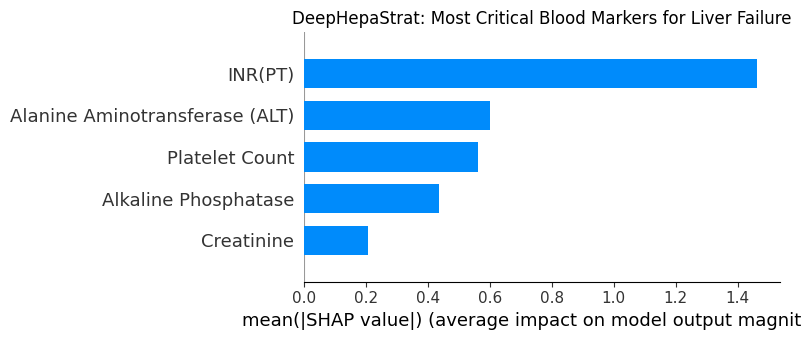

In [7]:
# 1. Install and import the SHAP library
!pip install shap -q
import shap
import matplotlib.pyplot as plt

print("Running SHAP Explainability Analysis...")

# 2. Build the Explainer
# We hand the SHAP tool your trained XGBoost model and your study data
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# 3. Plot the Feature Importance graph
# This creates a beautiful visual showing EXACTLY what the AI cares about
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)

# Add some nice titles for your college presentation
plt.title("DeepHepaStrat: Most Critical Blood Markers for Liver Failure")
plt.tight_layout()
plt.show()